# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils as utils
import torch.nn.functional as F

import torch.fft
from typing import Callable, List, Union    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Loading Data and Preprocessing

In [2]:
features_path = "data/friction_data/features_converged.csv"
targets_path = "data/friction_data/targets_aging_converged.csv"
train_samples = 700

/tmp/ipykernel_458924/163623338.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bins = np.logspace(np.log10(feature.min()), np.log10(feature.max()), 100)


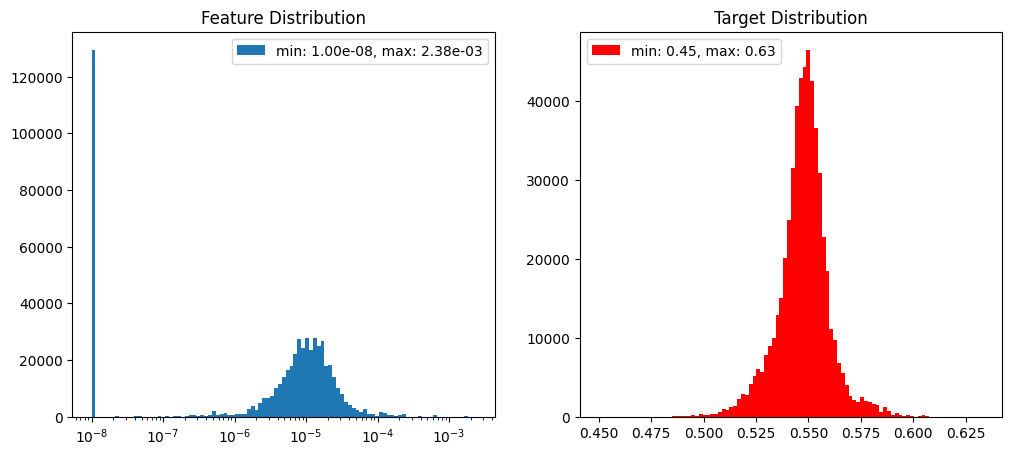

In [3]:
feature = torch.Tensor(np.genfromtxt(features_path, delimiter=',')[:, np.newaxis, :])
target = torch.Tensor(np.genfromtxt(targets_path, delimiter=',')[:, np.newaxis, :])

train_x = feature[:train_samples, :, :]
train_y = target[:train_samples, :, :]
test_x = feature[train_samples:, :, :]
test_y = target[train_samples:, :, :]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bins = np.logspace(np.log10(feature.min()), np.log10(feature.max()), 100)
axes[0].hist(feature.flatten(), bins=bins, label = f"min: {feature.min():.2e}, max: {feature.max():.2e}")
axes[0].set_xscale('log')
axes[0].set_title("Feature Distribution")
axes[0].legend()
axes[1].hist(target.flatten(), bins=100, color = 'red', label = f"min: {target.min():.2f}, max: {target.max():.2f}")
axes[1].set_title("Target Distribution")
axes[1].legend()

plt.show()

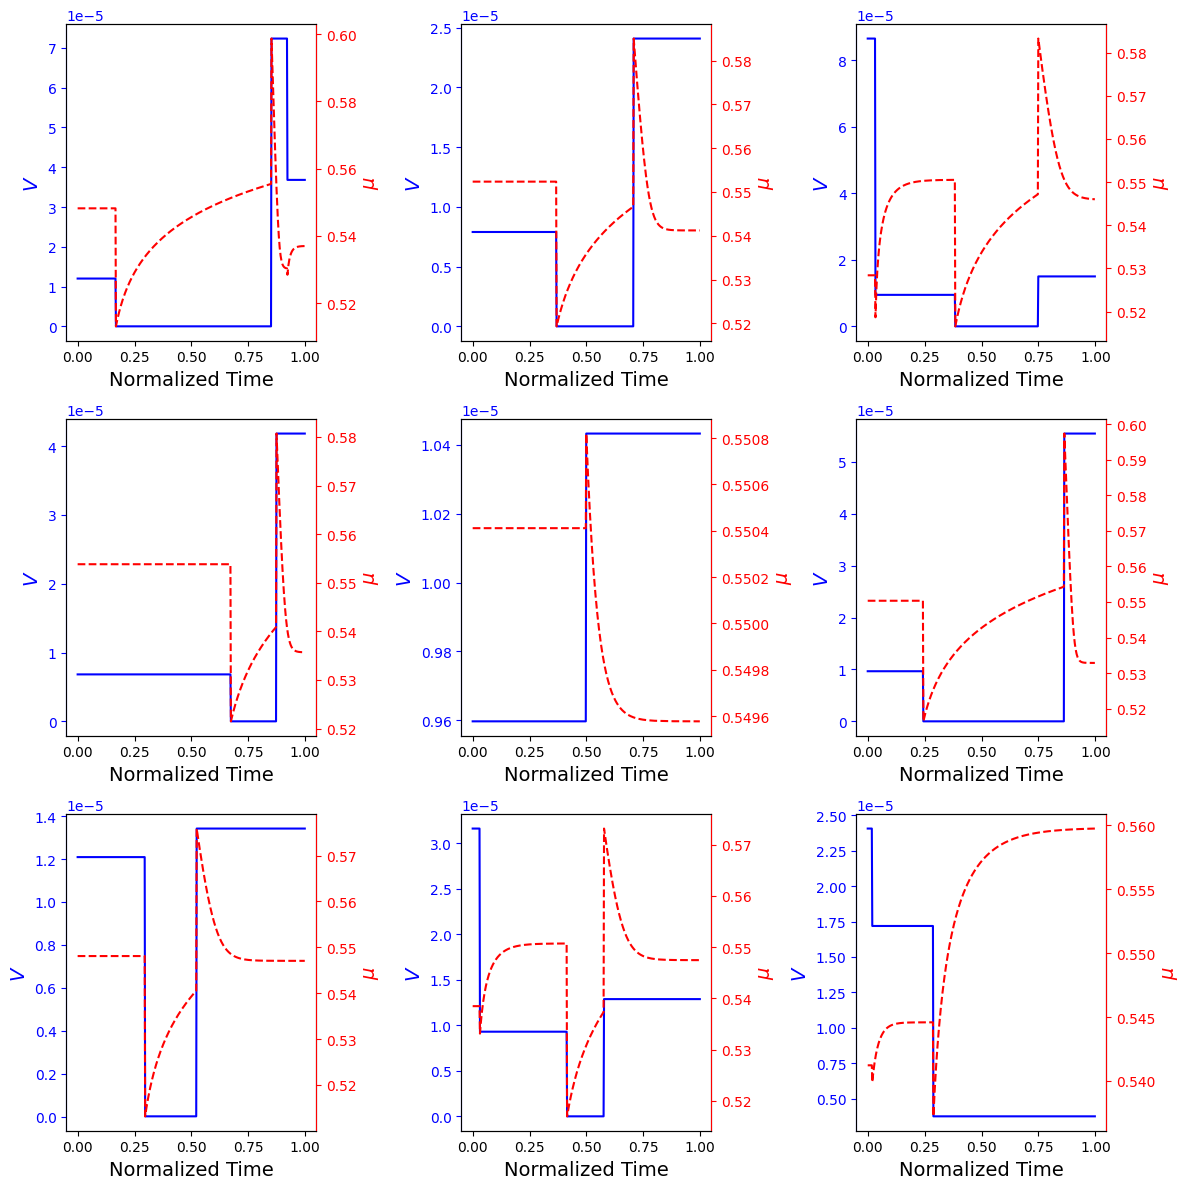

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, ax1 in enumerate(axes):
    # Velocity axis
    line1 = ax1.plot([i/len(feature[i,0,:]) for i in range(len(feature[i,0,:]))],
        feature[i, 0, :],
        color="blue",
        label=r"$V$"
    )
    ax1.set_xlabel("Normalized Time", fontsize = 14)
    ax1.set_ylabel(r"$V$", color="blue", fontsize = 14)
    ax1.tick_params(axis="y", colors="blue")
    ax1.spines["left"].set_color("blue")

    # Friction coefficient axis
    ax2 = ax1.twinx()
    line2 = ax2.plot([i/len(feature[i,0,:]) for i in range(len(feature[i,0,:]))],
        target[i, 0, :],
        color="red",
        label=r"$\mu$",
        linestyle = '--'
    )
    ax2.set_ylabel(r"$\mu$", color="red", fontsize = 14)
    ax2.tick_params(axis="y", colors="red")
    ax2.spines["right"].set_color("red")

    # Combined legend
    # lines = line1 + line2
    # labels = [l.get_label() for l in lines]
    # ax1.legend(lines, labels, loc="lower right")

plt.tight_layout()
plt.show()

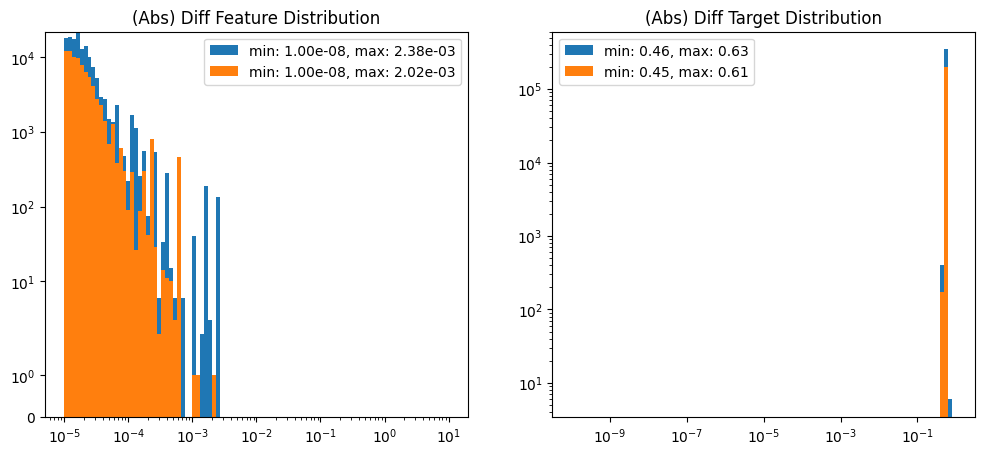

In [5]:
def transform_vel_diff(x, V_ref = 1e-5):
    return torch.log10(x[:,:,1:]/V_ref) - torch.log10(x[:,:,:-1]/V_ref)

def transform_mu_diff(x):
    return x[:,:,1:] - x[:,:,:-1]

train_x_trans = transform_vel_diff(train_x)
train_y_trans = transform_mu_diff(train_y)
test_x_trans = transform_vel_diff(test_x)
test_y_trans = transform_mu_diff(test_y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bins = np.logspace(np.log10(1e-5), np.log10(10), 100)
axes[0].hist(abs(train_x.flatten()), bins=bins, label = f"min: {abs(train_x).min():.2e}, max: {abs(train_x).max():.2e}")
axes[0].hist(abs(test_x.flatten()), bins=bins, label = f"min: {abs(test_x).min():.2e}, max: {abs(test_x).max():.2e}")
axes[0].set_xscale('log')
axes[0].set_yscale('symlog')
axes[0].set_title("(Abs) Diff Feature Distribution")
axes[0].legend()

bins = np.logspace(np.log10(1e-10), np.log10(1), 100)
axes[1].hist(abs(train_y).flatten(), bins=bins, label = f"min: {abs(train_y).min():.2f}, max: {abs(train_y).max():.2f}")
axes[1].hist(abs(test_y).flatten(), bins=bins, label = f"min: {abs(test_y).min():.2f}, max: {abs(test_y).max():.2f}")
axes[1].set_title("(Abs) Diff Target Distribution")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()

plt.show()

In [6]:
def x_state_transform(x: np.array) -> torch.Tensor:
    return torch.Tensor(np.sqrt(np.log(1e8*x)))

def log_transform(train, test, nonZero_tol = 0):
    train_idx = np.argwhere(train.flatten())[0]
    train_norm_state = x_state_transform(torch.abs(train.flatten()[train_idx]))
    train_min, train_max = train_norm_state.min(), train_norm_state.max()
    train_norm_state = (train_norm_state - train_min) / (train_max - train_min)

    test_idx = np.argwhere(test.flatten())[0]
    test_norm_state = x_state_transform(torch.abs(test.flatten()[test_idx]))
    test_norm_state = (test_norm_state - train_min) / (train_max - train_min)

    train_sign = torch.sign(train)
    test_sign = torch.sign(test)

    train_norm = torch.zeros_like(train.flatten())
    train_norm[train_idx] = train_norm_state

    test_norm = torch.zeros_like(test.flatten())
    test_norm[test_idx] = test_norm_state

    train_norm = train_norm.reshape(*train.shape)
    test_norm = test_norm.reshape(*test.shape)

    train_norm = train_norm * train_sign
    test_norm = test_norm * test_sign

    return train_norm, test_norm, (train_min, train_max)

train_x_norm, test_x_norm, (vel_min, vel_max) = log_transform(train_x_trans, test_x_trans)
train_y_norm, test_y_norm, (mu_min, mu_max) = log_transform(train_y_trans, test_y_trans)

/tmp/ipykernel_458924/3589211040.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.Tensor(np.sqrt(np.log(1e8*x)))


/tmp/ipykernel_458924/3811868631.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_458924/3811868631.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


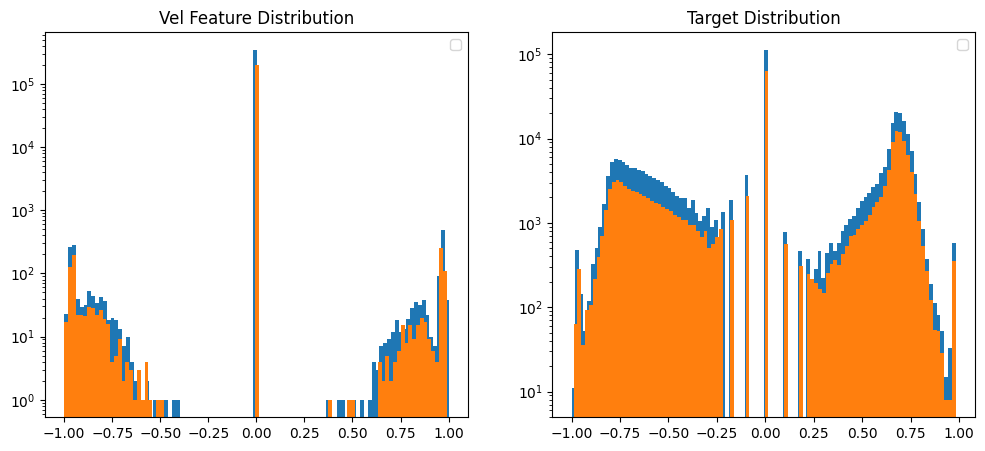

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(train_x_norm.flatten(), bins=100)
axes[0].hist(test_x_norm.flatten(), bins=100)
axes[0].set_yscale('log')
axes[0].set_title("Vel Feature Distribution")
axes[0].legend()

axes[1].hist(train_y_norm.flatten(), bins = 100)
axes[1].hist(test_y_norm.flatten(), bins = 100)
axes[1].set_yscale('log')
axes[1].set_title("Target Distribution")
axes[1].legend()

plt.show()

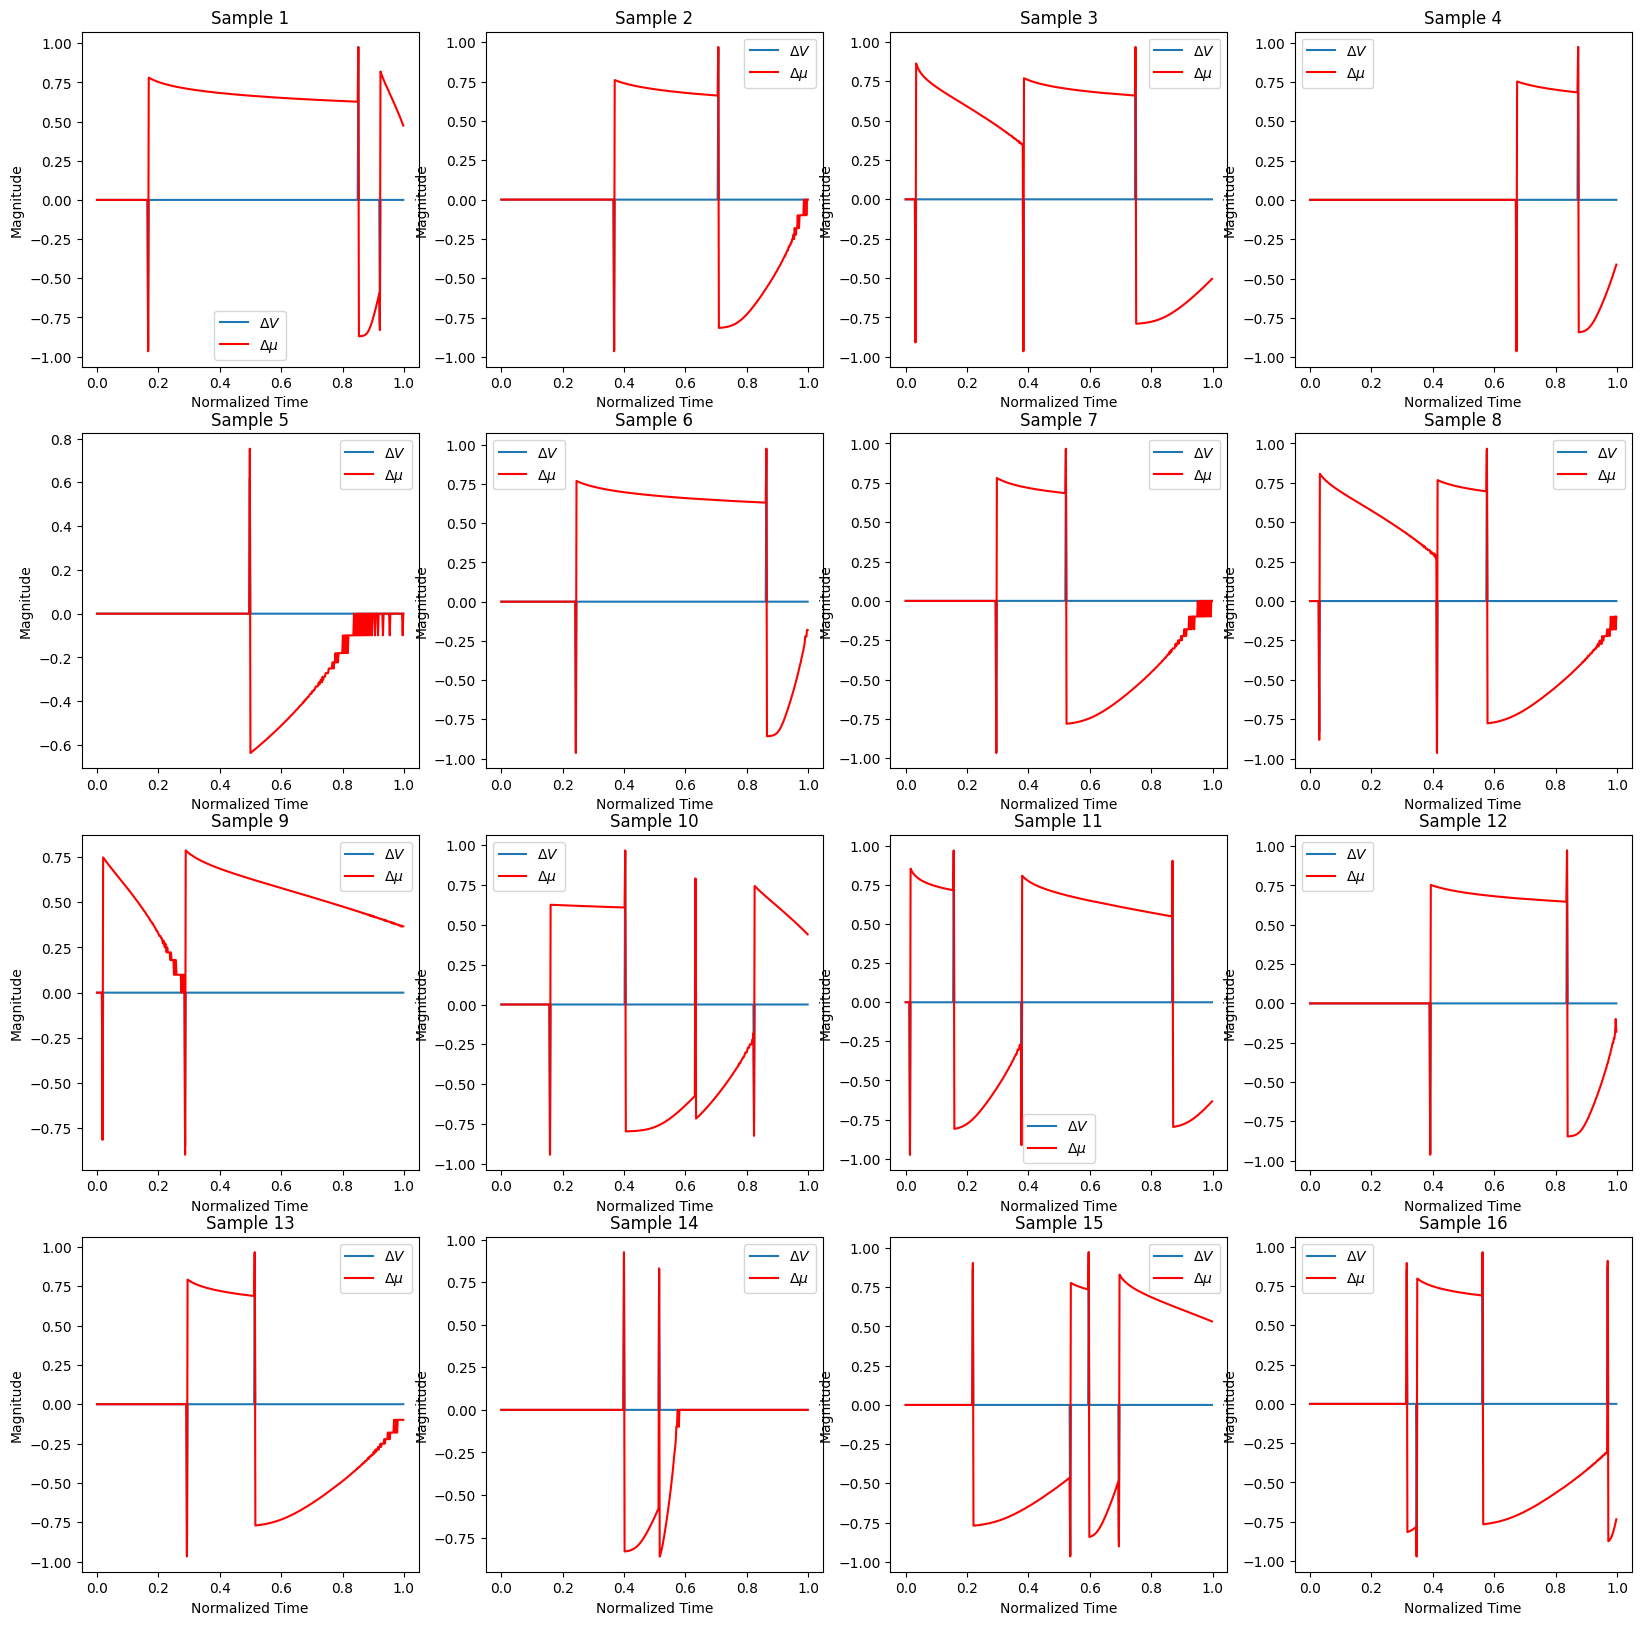

In [12]:
fig, axes = plt.subplots(4,4, figsize=(20, 20))
axes = axes.flatten()
for i in range(16):
    norm_time = [i/len(train_x_norm[i, 0, :]) for i in range(len(train_x_norm[i, 0, :]))]
    axes[i].plot(norm_time, train_x_norm[i, 0, :].numpy(), label=r'$\Delta V$')
    axes[i].plot(norm_time, train_y_norm[i, 0, :].numpy(), label=r'$\Delta \mu$', color = 'red')
    axes[i].set_title(f"Sample {i+1}")
    axes[i].set_xlabel('Normalized Time')
    axes[i].set_ylabel('Magnitude')
    axes[i].legend()

In [13]:
idx_to_keep = np.where(train_y_norm[:,0,-1] < 1e-8)
train_x_norm, train_y_norm = train_x_norm[idx_to_keep], train_y_norm[idx_to_keep]

idx_to_keep = np.where(test_y_norm[:,0,-1] < 1e-8)
test_x_norm, test_y_norm = test_x_norm[idx_to_keep], test_y_norm[idx_to_keep]

print(train_x_norm.shape, test_x_norm.shape)

train_dataset = TensorDataset(train_x_norm, train_y_norm)
test_dataset = TensorDataset(test_x_norm, test_y_norm)

torch.Size([532, 1, 498]) torch.Size([304, 1, 498])


# Code for Models, Training, Postprocessing

## FNO and NN

In [14]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)


class SpectralConv1d(nn.Module):
    def __init__(self, 
                 in_channels : int, 
                 out_channels: int, 
                 modes: int):
        """
        Initializes a 1D spectral convolution layer using complex weights in the Fourier domain.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            modes (int): Number of Fourier modes to retain (low-frequency modes).
        """
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        scale = 1.0 / (in_channels * out_channels)
        self.real_weights = nn.Parameter(
            torch.rand(in_channels, out_channels, modes) * 2 * scale - scale
        )
        self.imag_weights = nn.Parameter(
            torch.rand(in_channels, out_channels, modes) * 2 * scale - scale
        )

    def complex_mult1d(self, x_hat, w):
        return torch.einsum("iM,ioM->oM", x_hat, w)

    def forward(self, x):
        # x: (batch, channels, spatial_points)
        batchsize, channels, spatial_points = x.shape

        x_hat = torch.fft.rfft(x, dim=-1)  # (B, C, F)
        x_hat_under_modes = x_hat[:, :, :self.modes]

        weights = torch.complex(self.real_weights, self.imag_weights)
        out_hat_under_modes = torch.einsum("bim, iom -> bom", x_hat_under_modes, weights)

        out_hat = torch.zeros(
            batchsize, self.out_channels, x_hat.shape[-1],
            dtype=torch.cfloat, device=x.device
        )
        out_hat[:, :, :self.modes] = out_hat_under_modes

        out = torch.fft.irfft(out_hat, n=spatial_points, dim=-1)
        return out


class FNOBlock1d(nn.Module):
    def __init__(self, 
                 in_channels : int, 
                 out_channels : int, 
                 modes : int, 
                 activation : nn.Module = nn.Identity()):
        """
        Initializes a single Fourier Neural Operator (FNO) block for 1D data.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            modes (int): Number of retained Fourier modes in the spectral convolution.
            activation (nn.Module, optional): Activation function applied after the block output. Default is nn.Identity().
        """
        
        super().__init__()
        self.activation = activation
        self.spectral_conv = SpectralConv1d(in_channels, out_channels, modes)
        self.bypass_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        sc = self.spectral_conv(x)
        bc = self.bypass_conv(x)
        out = sc + bc
        out = self.activation(out)
        return out

class Projection_NN(nn.Module):
    def __init__(self, 
                 input_dim : int, 
                 output_dim : int, 
                 width : int, 
                 depth : int, 
                 activation: nn.Module = nn.Identity(),
                 dropout = 0,
                 batchNorm = False):
        
        """
        Initializes a fully-connected feedforward projection network.

        Args:
            input_dim (int): Input dimensionality.
            output_dim (int): Output dimensionality.
            width (int): Width (number of hidden units) in each hidden layer.
            depth (int): Number of layers in the network (including input/output layers).
            activation (nn.Module, optional): Activation function applied between layers. Default is nn.Identity().
        """
        
        super().__init__()

        layers = [nn.Linear(input_dim, width)]
        layers.append(activation)
        layers.append(nn.Dropout(dropout))
        layers.append(nn.BatchNorm1d(width) if batchNorm else nn.Identity())

        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            layers.append(activation)
            layers.append(nn.Dropout(dropout))
            layers.append(nn.BatchNorm1d(width) if batchNorm else nn.Identity())

        layers.append(nn.Linear(width, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        bsize, _, N = x.shape
        x = x.permute(0, 2, 1).contiguous().view(-1, self.network[0].in_features)
        x = self.network(x)
        x = x.view(bsize, N, self.network[-1].out_features).permute(0, 2, 1).contiguous()
        return x

class FNO1d(nn.Module):
    def __init__(
        self,
        in_channels : int,
        out_channels : int,
        modes : int,
        width : int,
        block_activation : nn.Module = nn.Identity(),
        n_blocks : int = 4,
        padding : int = 0,
        lift_network = None,
        decode_network = None,
    ):
        """
        Initializes a 1D Fourier Neural Operator (FNO) model.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            modes (int): Number of Fourier modes retained in spectral convolutions.
            width (int): Width of the internal FNO layers.
            block_activation (nn.Module, optional): Activation applied after each FNO block. Default is nn.Identity().
            n_blocks (int, optional): Number of stacked FNO blocks. Default is 4.
            padding (int, optional): Amount of zero-padding added to input and removed from output. Default is 0.
        """

        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.width = width
        self.block_activation = block_activation
        self.n_blocks = n_blocks
        self.padding = padding
        
        self.lift_network = lift_network
        self.decode_network = decode_network

        self.fno_blocks = nn.ModuleList([
            FNOBlock1d(width, width, modes, block_activation)
            for _ in range(n_blocks)
        ])

        self.apply(init_weights)

    # x: (B, C, N)
    def forward(self, x):

        x = self.lift_network(x)

        N = x.shape[-1]
        target_length = (1 << (N - 1).bit_length()) * 2

        total_pad = target_length - N
        pad_left = total_pad // 2
        pad_right = total_pad - pad_left

        if total_pad > 0:
            x = nn.functional.pad(
                x,
                (pad_left, pad_right),
                mode="constant",
                value=0,
            )

        for block in self.fno_blocks:
            x = block(x)

        x = self.decode_network(x)

        if total_pad > 0:
            x = x[..., pad_left:pad_left + N]

        return x

## Train Loop

In [15]:
def train_loop(model,
                     train_loader,
                     test_loader,
                     epochs,
                     optimizer,
                     scheduler=None,
                     clip_grad=False,
                     mixed_training=False,
                     add_noise=False,
                     loss_func = nn.MSELoss(),
                     half_train = False):

    criterion = loss_func

    loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch_x, batch_y in train_loader:

            B,C,N = batch_x.shape
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            if half_train is not False:
                if np.random.random() > 0.5:
                    sample_N = int(torch.rand(1)*398+100)
                    batch_x = batch_x[:, :, :sample_N]
                    batch_y = batch_y[:, :, :sample_N]
                    batch_x = torch.nn.functional.interpolate(batch_x,N)
                    batch_y = torch.nn.functional.interpolate(batch_y,N)

            if mixed_training is not False:
                sample_freq = np.random.choice(mixed_training[0], p=mixed_training[1])
                batch_x = batch_x.to(device)[:, :, ::sample_freq]
                batch_y = batch_y.to(device)[:, :, ::sample_freq]

            if add_noise is not False:
                noise = torch.randn_like(batch_x) * add_noise[0]
                batch_x = batch_x + noise

            def closure():
                optimizer.zero_grad()

                output = model(batch_x)
                loss = criterion(output, batch_y)

                loss.backward()

                if clip_grad:
                    utils.clip_grad_norm_(model.parameters(), 0.5)

                return loss

            loss = optimizer.step(closure)

            epoch_loss += loss.item()

        if scheduler is not None:
            scheduler.step()

        loss_history.append(epoch_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                val_output = model(batch_x)
                val_loss += criterion(val_output, batch_y).item()

        val_loss_history.append(val_loss / len(test_loader))

        print(
            f"EPOCH {epoch}: "
            f"train_loss: {loss_history[-1]:.3e} \t "
            f"test_loss: {val_loss_history[-1]:.3e}"
        )

    return loss_history, val_loss_history

In [16]:
def make_decay_fn(factor: float, 
                  interval: int):
    return lambda step: factor ** (step // interval)

## Postprocessing

In [17]:
def plot_results(model, x, y, name):

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    axes = axes.flatten()
    for i in range(16):
        pred = model(x[i:i+1].to(device))[0].cpu().detach().numpy()
        ax1 = axes[i]

        ax1.plot(y[i, 0, :].cpu().detach().numpy(), color='tab:orange', label='Ground Truth' if i == 0 else "")
        ax1.plot(pred[0], color='tab:green', linestyle = '--', label='Prediction' if i == 0 else "")
        ax1.plot(x[i,0,:], color = 'k', label = 'input' if i==0 else '', alpha = 0.5)
        ax1.set_xticks([])
        ax1.set_yticks([])

    fig.suptitle(name, fontsize=22, y=0.98)

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  
    plt.show()

def plot_loss(loss, val, barometer = None):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(loss, label="train loss")
    ax.plot(val, label="val loss")
    if barometer is not None:
        ax.hlines(barometer, xmin = 0, xmax = len(loss), color = 'red', linestyle = '--')
    ax.legend(fontsize=14)
    ax.set_yscale("log")
    ax.grid(True)
    ax.tick_params(axis='both', which='major', labelsize=14)
    fig.suptitle("Loss History", fontsize=18)
    plt.tight_layout()
    plt.show()

# Training

In [18]:
in_channels = train_x_norm.shape[1]
width = 32
out_channels = 1

lift_network = Projection_NN(
                input_dim = in_channels,
                output_dim = width,
                width = 64,
                depth = 2,
                activation = torch.nn.GELU(),
                dropout = 0.05
            )

decode_network = Projection_NN(
                input_dim = width,
                output_dim = out_channels,
                width = 64,
                depth = 2,
                activation = torch.nn.GELU(),
                dropout = 0.05
            )

model = FNO1d(
        in_channels=in_channels,
        out_channels=out_channels,
        modes = 12,
        width=width,
        block_activation=torch.nn.Mish(),
        n_blocks=4,
        padding=0,
        lift_network=lift_network,
        decode_network=decode_network,
        ).to(device)


lr = 1e-3

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda= make_decay_fn(0.999, 100))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

loss_history, val_loss_history = [], []

loss_history, val_loss_history = train_loop(model, train_loader, test_loader,
                                            1000, optimizer, scheduler,
                                            mixed_training=False,
                                            half_train = True,
                                            clip_grad = True)

EPOCH 0: train_loss: 2.224e-01 	 test_loss: 2.716e-01
EPOCH 1: train_loss: 2.216e-01 	 test_loss: 2.653e-01
EPOCH 2: train_loss: 1.906e-01 	 test_loss: 2.468e-01
EPOCH 3: train_loss: 1.855e-01 	 test_loss: 2.125e-01
EPOCH 4: train_loss: 1.635e-01 	 test_loss: 1.437e-01
EPOCH 5: train_loss: 1.263e-01 	 test_loss: 1.069e-01
EPOCH 6: train_loss: 1.108e-01 	 test_loss: 9.370e-02
EPOCH 7: train_loss: 1.135e-01 	 test_loss: 8.933e-02
EPOCH 8: train_loss: 1.146e-01 	 test_loss: 1.115e-01
EPOCH 9: train_loss: 1.220e-01 	 test_loss: 1.178e-01
EPOCH 10: train_loss: 1.093e-01 	 test_loss: 8.202e-02
EPOCH 11: train_loss: 1.181e-01 	 test_loss: 9.653e-02
EPOCH 12: train_loss: 1.023e-01 	 test_loss: 1.150e-01
EPOCH 13: train_loss: 1.076e-01 	 test_loss: 8.990e-02
EPOCH 14: train_loss: 1.032e-01 	 test_loss: 7.683e-02
EPOCH 15: train_loss: 1.113e-01 	 test_loss: 9.826e-02
EPOCH 16: train_loss: 1.163e-01 	 test_loss: 1.115e-01
EPOCH 17: train_loss: 9.466e-02 	 test_loss: 8.766e-02
EPOCH 18: train_loss

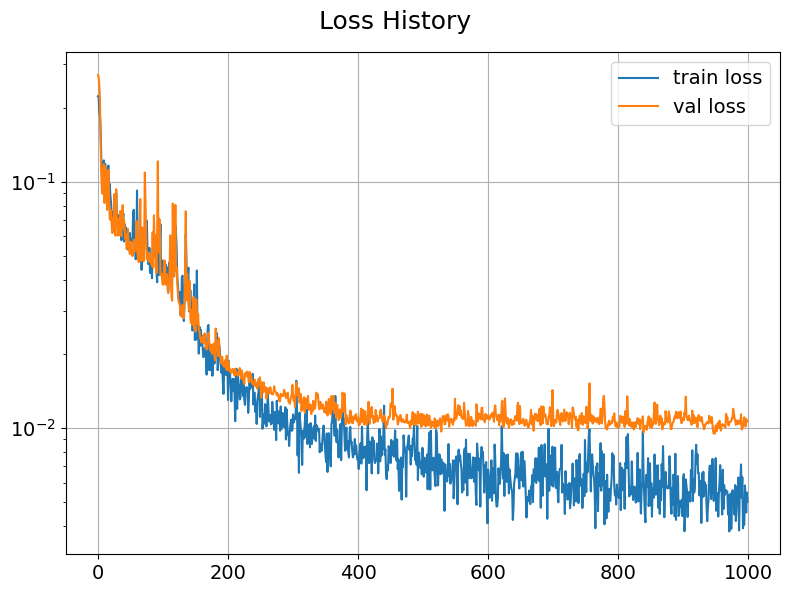

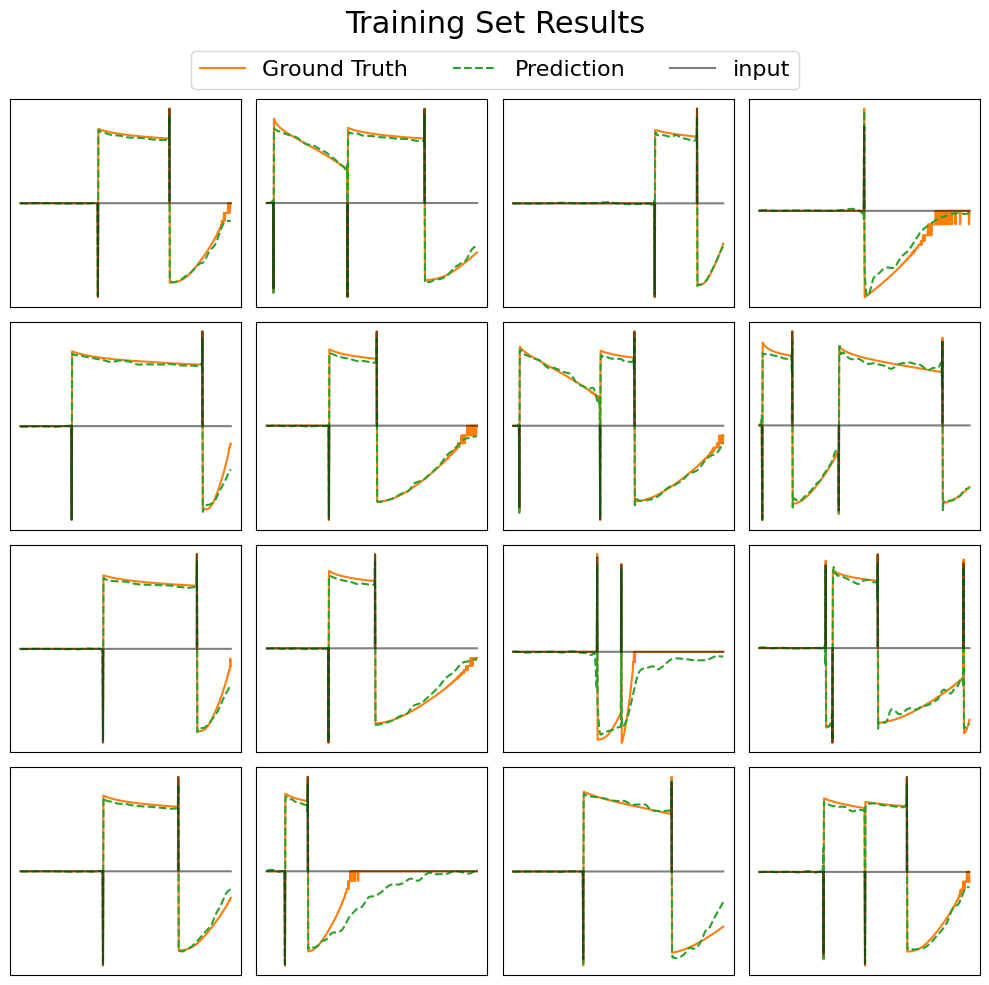

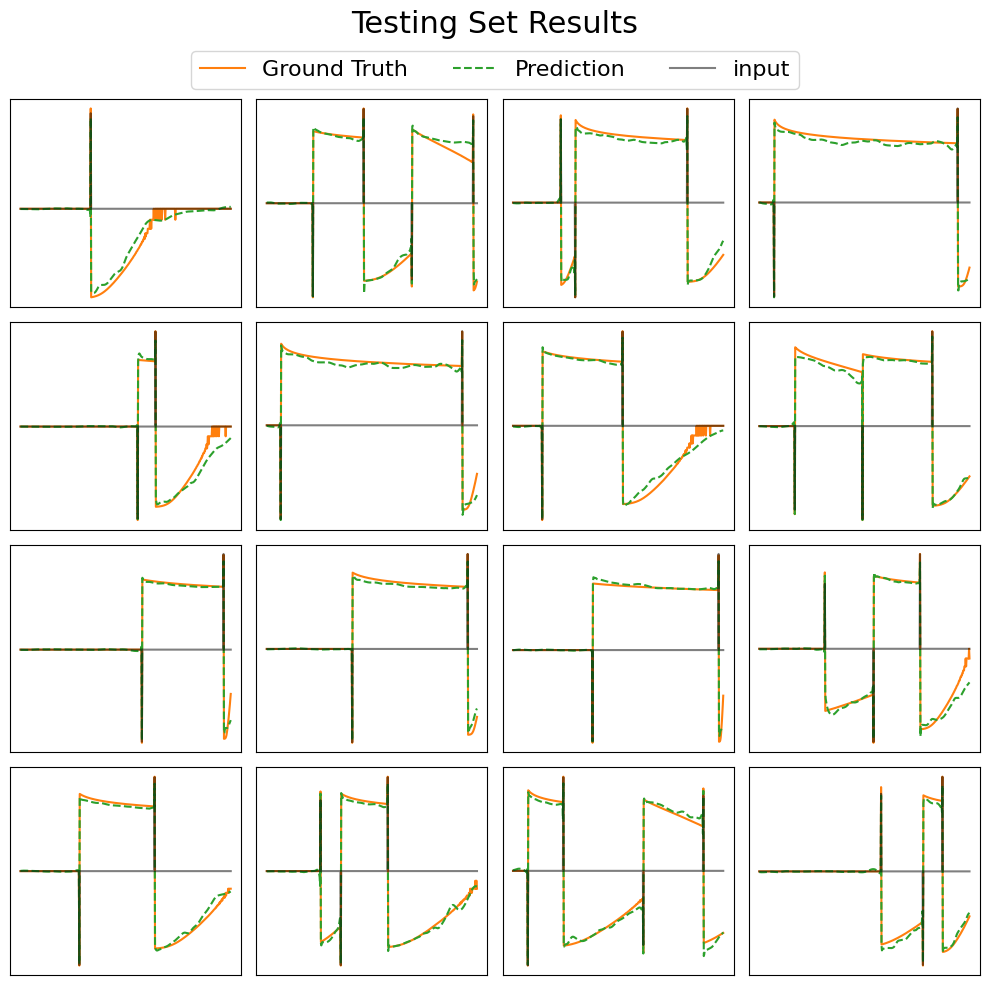

In [19]:
plot_loss(loss_history, val_loss_history)
plot_results(model, train_x_norm, train_y_norm, "Training Set Results")
plot_results(model, test_x_norm, test_y_norm, "Testing Set Results")